# 2026 Dutch Grand Prix — Model

The live demo. Every number here is loaded from artifacts produced by `src/`;
**no model is fitted in this notebook.** To regenerate:

```
uv run python src/backtest.py
uv run python src/predict_dutch.py
```

**The design in one line:** predict *finishing position* (a regression over ~320
rows), then recover win and podium probabilities by simulating the race 20,000
times. Not a win classifier — there are only 16 winners in the whole dataset.

**Portable:** this notebook reads saved artifacts only. It needs `pandas`,
`numpy` and `matplotlib` and nothing more, so it runs on any interpreter that
has them — it is not tied to the project virtualenv.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE))

from src import viz

viz.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

REPORTS = BASE / "reports"
PREDICTIONS = BASE / "predictions"

backtest = pd.read_csv(REPORTS / "backtest_results.csv", index_col=0)
folds = pd.read_csv(REPORTS / "backtest_folds.csv")
selection = json.loads((REPORTS / "model_selection.json").read_text())
prediction = json.loads((PREDICTIONS / "2026_R12_dutch.json").read_text())
pred_table = pd.read_csv(PREDICTIONS / "2026_R12_dutch.csv")

SELECTED = selection["selected_model"]
SIGMA = selection["residual_sigma"]

print("selected model :", SELECTED)
print("residual sigma :", round(SIGMA, 3), "positions")
print("locked at      :", prediction["generated_at_utc"])

selected model : A_ridge
residual sigma : 4.624 positions
locked at      : 2026-08-23T12:09:31+00:00


## 1. Backtest — walk-forward, rounds 6 to 11

Train on every round before *k*, predict round *k*'s race, score, move on. Sprints
are used for training but never as a test fold.

In [2]:
show = backtest.drop(columns=[c for c in ["label"] if c in backtest.columns])
styled = show.round(4)
print("ranked by win log loss (lower is better)\n")
print(styled.to_string())

best_overall = backtest["win_log_loss"].idxmin()
print(f"\nselected (best FITTED model): {SELECTED}")
print(f"best of everything tested   : {best_overall}")
print(f"beats B1 and B4?            : {selection['beats_baselines']}")

ranked by win log loss (lower is better)

                      n_folds  win_log_loss  win_brier  podium_log_loss  podium_brier  top1_hit  spearman_rho  mae_position  p_actual_winner  sigma_test  sigma_cv
model                                                                                                                                                             
D_grid_baseline             6        0.0982     0.0298           0.2227        0.0714    0.6667        0.6701        3.2879           0.2596      5.0454    4.6764
A_ridge                     6        0.1142     0.0338           0.2418        0.0774    0.5000        0.6725        3.4030           0.1957      4.6238    4.3937
B_random_forest             6        0.1186     0.0349           0.2542        0.0826    0.3333        0.6836        3.3088           0.1880      4.6092    4.4899
C_gradient_boosting         6        0.1449     0.0396           0.2988        0.0997    0.1667        0.6657        3.5130           0.1529   

**The headline result, stated plainly: the fitted models did not beat the grid
baseline.** `A_ridge` is the best of the three fitted candidates and it beats B1
(pole-sitter wins), B2 (championship leader wins) and B3 (uniform) comfortably on
win log loss — but B4, "assume everyone finishes where they started", beats all of
them at 0.0982 against Ridge's 0.1142.

That is reported rather than tuned away. Grid position is by far the strongest
single signal in the data (Spearman ρ = 0.745, highest mutual information of any
feature), the other thirteen features are heavily collinear with it, and ~320
training rows is not enough for a fitted model to add signal faster than it adds
variance. Six test races cannot separate methods this close together either.

## 2. Calibration

Do the probabilities mean what they say? A model claiming 20% should be right
about one time in five.

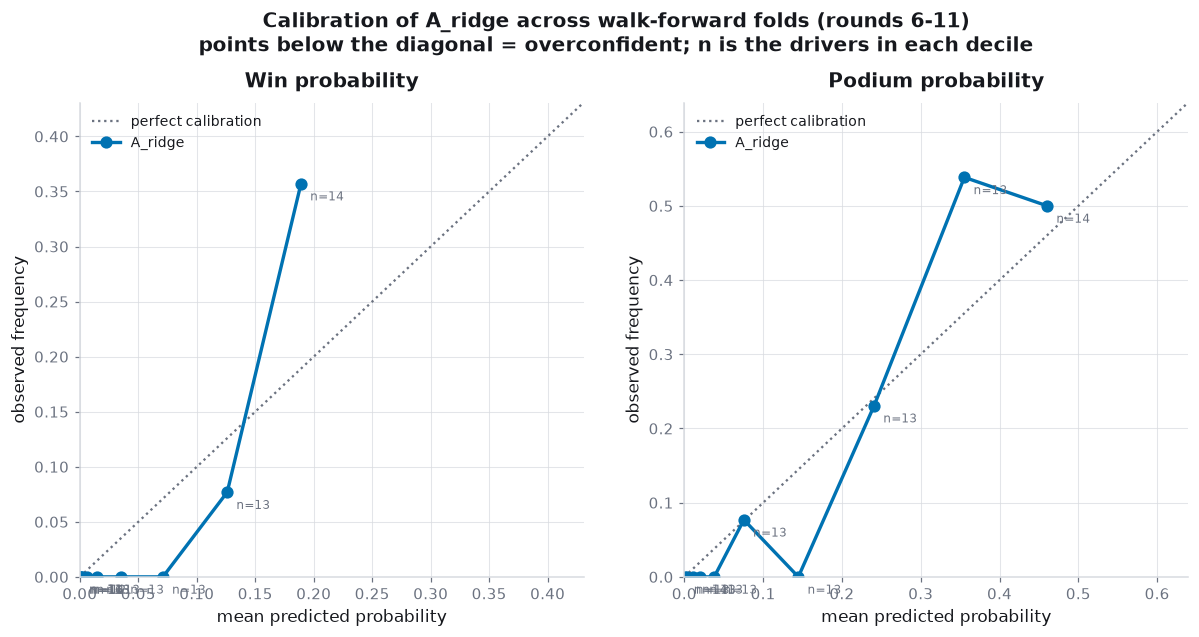

target  decile  mean_predicted  observed  n   model
   win       1          0.0000    0.0000 16 A_ridge
   win       2          0.0003    0.0000 11 A_ridge
   win       3          0.0014    0.0000 14 A_ridge
   win       4          0.0030    0.0000 12 A_ridge
   win       5          0.0063    0.0000 13 A_ridge
   win       6          0.0147    0.0000 13 A_ridge
   win       7          0.0353    0.0000 13 A_ridge
   win       8          0.0710    0.0000 13 A_ridge
   win       9          0.1260    0.0769 13 A_ridge
   win      10          0.1891    0.3571 14 A_ridge
podium       1          0.0004    0.0000 14 A_ridge
podium       2          0.0030    0.0000 13 A_ridge
podium       3          0.0110    0.0000 13 A_ridge
podium       4          0.0201    0.0000 13 A_ridge
podium       5          0.0379    0.0000 13 A_ridge
podium       6          0.0755    0.0769 13 A_ridge
podium       7          0.1447    0.0000 13 A_ridge
podium       8          0.2408    0.2308 13 A_ridge
podium      

In [3]:
# Drawn from reports/calibration.csv, the decile table src/backtest.py emits.
cal = pd.read_csv(REPORTS / "calibration.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, target, title in zip(axes, ["win", "podium"], ["Win probability", "Podium probability"]):
    d = cal[cal["target"] == target]
    top = max(d["mean_predicted"].max(), d["observed"].max()) * 1.15 + 0.02
    ax.plot([0, top], [0, top], linestyle=":", color=viz.MUTED, linewidth=1.5,
            label="perfect calibration")
    ax.plot(d["mean_predicted"], d["observed"], marker="o", color=viz.ACCENT,
            linewidth=2.2, markersize=7, label=SELECTED)
    for _, r in d.iterrows():
        ax.annotate(f"n={int(r['n'])}", (r["mean_predicted"], r["observed"]),
                    textcoords="offset points", xytext=(6, -11), fontsize=8, color=viz.MUTED)
    ax.set_xlim(0, top); ax.set_ylim(0, top)
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed frequency")
    ax.set_title(title)
    ax.legend(loc="upper left")
fig.suptitle(f"Calibration of {SELECTED} across walk-forward folds (rounds 6-11)\n"
             "points below the diagonal = overconfident; n is the drivers in each decile",
             fontsize=13, fontweight="bold", y=1.03)
plt.show()

print(cal.round(4).to_string(index=False))

Points below the diagonal mean overconfidence. With six races and roughly 130
driver-rows in total, the deciles are thin — the `n` annotations show how thin —
so this plot is a sanity check that nothing is grossly miscalibrated, not evidence
of good calibration. Establishing calibration properly needs far more races.

## 3. What the model actually uses

Permutation importance, measured on the held-out fold of each walk-forward split.
Impurity importance is deliberately not used: it is computed in-sample and is
biased toward high-cardinality features.

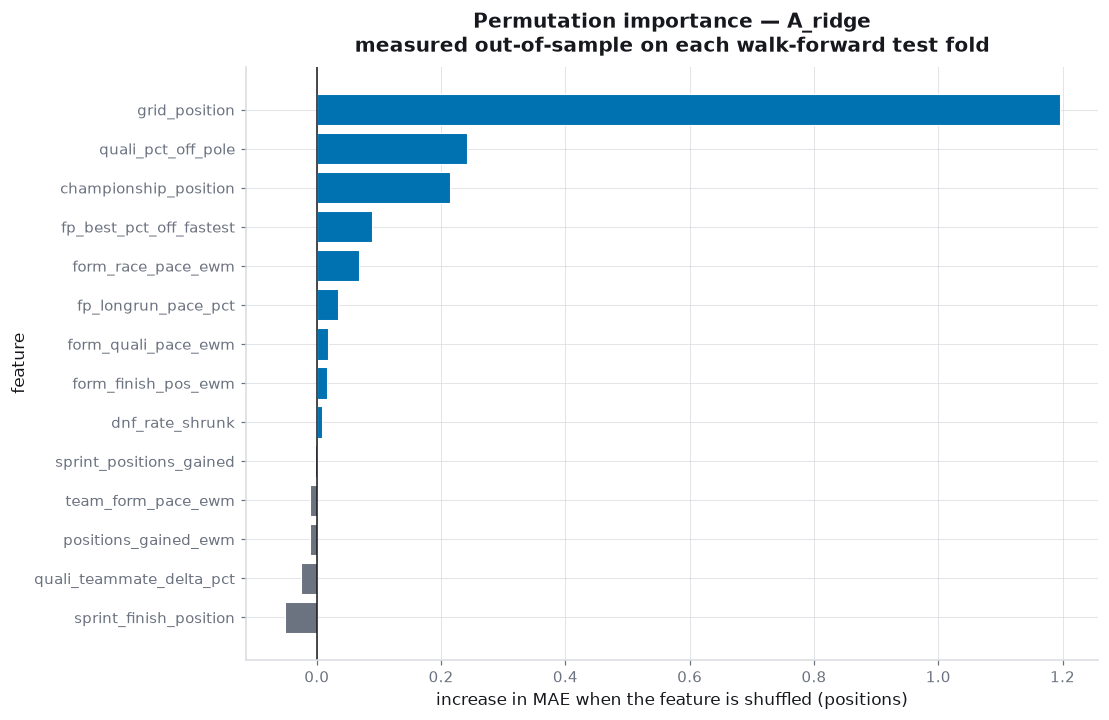

feature
grid_position               1.1952
quali_pct_off_pole          0.2414
championship_position       0.2147
fp_best_pct_off_fastest     0.0896
form_race_pace_ewm          0.0674
fp_longrun_pace_pct         0.0347
form_quali_pace_ewm         0.0184
form_finish_pos_ewm         0.0165
dnf_rate_shrunk             0.0084
sprint_positions_gained    -0.0024
team_form_pace_ewm         -0.0115
positions_gained_ewm       -0.0116
quali_teammate_delta_pct   -0.0254
sprint_finish_position     -0.0519


In [4]:
imp = pd.read_csv(REPORTS / "permutation_importance.csv")
sel_imp = (imp[imp["model"] == SELECTED]
           .set_index("feature")["importance"].sort_values())

fig, ax = plt.subplots(figsize=(10, 7))
colors = [viz.ACCENT if v > 0 else viz.MUTED for v in sel_imp]
ax.barh(sel_imp.index, sel_imp.to_numpy(), color=colors, edgecolor="white", linewidth=0.7)
ax.axvline(0, color=viz.INK, linewidth=1.0)
ax.set_xlabel("increase in MAE when the feature is shuffled (positions)")
ax.set_ylabel("feature")
ax.set_title(f"Permutation importance — {SELECTED}\n"
             "measured out-of-sample on each walk-forward test fold")
plt.show()

print(sel_imp.sort_values(ascending=False).round(4).to_string())

**What it shows.** How much worse the model gets when each feature is shuffled,
averaged over the held-out folds. Features at or below zero are doing nothing —
shuffling them does not hurt, which on this sample size means they are not
earning their place.

## 4. The locked prediction

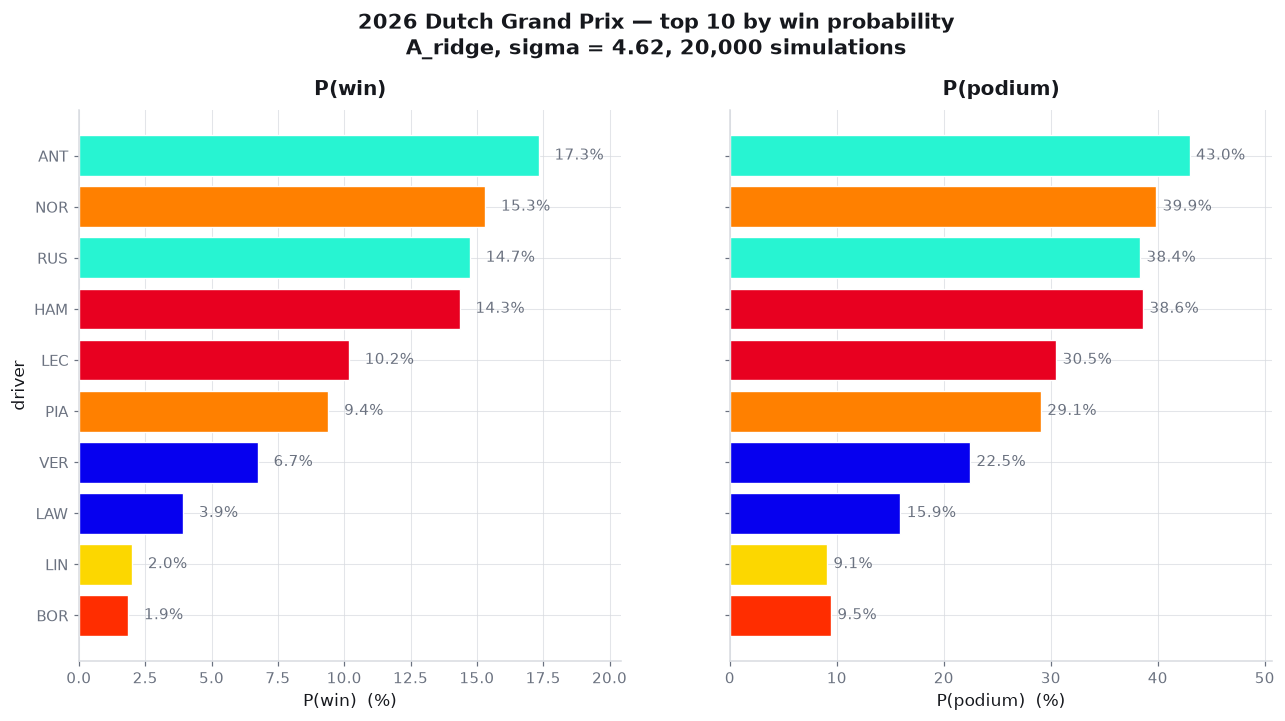

In [5]:
top10 = pred_table.head(10).iloc[::-1]  # reversed so the favourite sits on top
y = np.arange(len(top10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)
for ax, col, title in [(axes[0], "p_win", "P(win)"), (axes[1], "p_podium", "P(podium)")]:
    ax.barh(y, top10[col] * 100, color=top10["team_color"],
            edgecolor="white", linewidth=0.9)
    for yi, v in zip(y, top10[col] * 100):
        ax.text(v + 0.6, yi, f"{v:.1f}%", va="center", fontsize=9.5, color=viz.MUTED)
    ax.set_yticks(y)
    ax.set_yticklabels(top10["abbreviation"])
    ax.set_xlabel(f"{title}  (%)")
    ax.set_title(title)
    ax.set_xlim(0, float(top10[col].max() * 100) * 1.18)
axes[0].set_ylabel("driver")
fig.suptitle(f"{prediction['race']} — top 10 by win probability\n"
             f"{SELECTED}, sigma = {SIGMA:.2f}, "
             f"{prediction['simulation']['n_sims']:,} simulations",
             fontsize=14, fontweight="bold", y=1.02)
plt.show()

In [6]:
cols = ["abbreviation", "team_name", "grid_position", "predicted_position", "p_win", "p_podium"]
out = pred_table[cols].head(12).copy()
out["p_win"] = (out["p_win"] * 100).round(1).astype(str) + "%"
out["p_podium"] = (out["p_podium"] * 100).round(1).astype(str) + "%"
out["predicted_position"] = out["predicted_position"].round(2)
print(out.to_string(index=False))
print(f"\nsum of p_win = {pred_table['p_win'].sum():.6f}  (exactly one car wins each simulation)")
print(f"p_win <= p_podium for every driver: {(pred_table['p_win'] <= pred_table['p_podium']).all()}")

abbreviation       team_name  grid_position  predicted_position p_win p_podium
         ANT        Mercedes            3.0                4.54 17.3%    43.0%
         NOR         McLaren            1.0                4.69 15.3%    39.9%
         RUS        Mercedes            2.0                4.80 14.7%    38.4%
         HAM         Ferrari            5.0                5.21 14.3%    38.6%
         LEC         Ferrari            6.0                5.95 10.2%    30.5%
         PIA         McLaren            4.0                6.34  9.4%    29.1%
         VER Red Bull Racing            7.0                6.95  6.7%    22.5%
         LAW Red Bull Racing            8.0                8.47  3.9%    15.9%
         LIN    Racing Bulls           10.0               10.19  2.0%     9.1%
         BOR            Audi            9.0               10.06  1.9%     9.5%
         GAS          Alpine           11.0               10.26  1.6%     8.5%
         COL          Alpine           14.0         

## 5. What the model believes, and why

**In plain English.** The model expects a Mercedes-led race. It puts Antonelli
just ahead of Norris despite Norris starting on pole, because Antonelli leads the
championship, has the stronger recent form on every rolling measure, and Mercedes
has been the fastest car in qualifying all season (0.22% median gap to pole against
McLaren's 0.58%). The model is reading *season-long form* over *one qualifying lap*.

**How confident is it? Barely.** The favourite gets about 17%, and the top six are
packed between roughly 9% and 17%. That flatness is not vagueness for its own sake
— it is the fitted residual sigma of **4.6 positions** doing its job. Over the
backtest, this model's predicted finishing position was off by 4.6 positions on
average, so the simulation spreads outcomes accordingly. A model claiming 60% for
anyone on this evidence would be lying.

**What it is ignoring, and this is the risk.** Zandvoort is the hardest circuit of
the 2026 season to overtake at — lowest of all twelve on position change, even
after excluding retirements. The model has no circuit-specific term, so it does not
know that starting position matters *more* here than the season average implies.
That is precisely the situation where B4, which is pure grid order, is likely to
beat it. **Norris on pole is the bet the model is declining to make, and the
backtest says the model is probably wrong to decline it.**

**And what it cannot see at all**: tyre strategy, safety cars, the weather on
Sunday, and whether a grid penalty has moved anyone since qualifying.